In [3]:
import pandas as pd
import numpy as np

from pathlib import Path

In [10]:
from pathlib import Path

DATA_PATH = Path("../data/final_tourist_data.csv")

In [11]:
df = pd.read_csv(DATA_PATH)

In [12]:
df.head(10)

,year,guest_nights,region,month,date,occupancy_rate,guest_lag1,guest_lag2,guest_lag12,occ_lag1,...,rain_mean,occupancy_rate_total,occupancy_vs_total,sunny_days,mean_sun_hours,total_sun_hours,eur,usd,nok,dkk
0,2016,899950,dalarna,7,2016-07-01,0.651423,294049.0,157406.0,815341.0,0.382347,...,3.393548,0.689116,-0.037693,20,9.234400,286.266389,9.47149,8.56058,1.01087,1.27321
1,2016,551055,norrbotten,7,2016-07-01,0.543563,213093.0,129740.0,516109.0,0.406692,...,3.696774,0.689116,-0.145553,23,10.175735,315.447778,9.47149,8.56058,1.01087,1.27321
2,2016,375313,vasterbotten,7,2016-07-01,0.577188,156829.0,110225.0,351895.0,0.482250,...,2.651613,0.689116,-0.111928,24,9.903790,307.017500,9.47149,8.56058,1.01087,1.27321
3,2016,377219,jamtland,7,2016-07-01,0.582445,129819.0,67308.0,342708.0,0.367817,...,2.267742,0.689116,-0.106671,21,9.321828,288.976667,9.47149,8.56058,1.01087,1.27321
4,2016,266737,vasternorrland,7,2016-07-01,0.575731,116763.0,83850.0,264611.0,0.453449,...,1.341935,0.689116,-0.113385,27,9.220194,285.826007,9.47149,8.56058,1.01087,1.27321
5,2016,2258817,vastragotaland,7,2016-07-01,0.775082,1093499.0,880628.0,2357140.0,0.671991,...,2.383871,0.689116,0.085966,17,6.512661,201.892500,9.47149,8.56058,1.01087,1.27321
6,2016,359356,gotland,7,2016-07-01,0.872610,137639.0,82460.0,316031.0,0.575576,...,1.058065,0.689116,0.183493,27,11.409471,353.693611,9.47149,8.56058,1.01087,1.27321
7,2016,1628450,stockholm,7,2016-07-01,0.705716,1269965.0,1213399.0,1680753.0,0.709836,...,2.225806,0.689116,0.016599,25,10.118808,313.683056,9.47149,8.56058,1.01087,1.27321
8,2016,1222152,skane,7,2016-07-01,0.764457,624678.0,534615.0,1200125.0,0.645685,...,2.645161,0.689116,0.075341,16,7.084857,219.630556,9.47149,8.56058,1.01087,1.27321
9,2016,312168,norrbotten,8,2016-08-01,0.483953,551055.0,213093.0,294803.0,0.543563,...,2.754839,0.656746,-0.172792,16,6.610941,204.939167,9.49340,8.47139,1.01956,1.27592


In [13]:
df.shape

(1028, 23)

In [14]:
df["region"].nunique()

9

In [15]:
df.isna().sum().sort_values(ascending=False)

year                    0
rain_days               0
nok                     0
usd                     0
eur                     0
total_sun_hours         0
mean_sun_hours          0
sunny_days              0
occupancy_vs_total      0
occupancy_rate_total    0
rain_mean               0
rain_sum                0
guest_nights            0
temp_mean               0
occ_lag1                0
guest_lag12             0
guest_lag2              0
guest_lag1              0
occupancy_rate          0
date                    0
month                   0
region                  0
dkk                     0
dtype: int64

In [16]:
df["guest_nights"].describe()

count    1.028000e+03
mean     4.048998e+05
std      4.358389e+05
min      8.096000e+03
25%      1.129130e+05
50%      2.314745e+05
75%      5.348932e+05
max      2.561995e+06
Name: guest_nights, dtype: float64

In [18]:
df.groupby("region")["guest_nights"].mean().sort_values(ascending=False)

region
stockholm         1.123677e+06
vastragotaland    8.340369e+05
skane             5.025746e+05
dalarna           4.100016e+05
jamtland          2.354611e+05
norrbotten        2.103806e+05
vasterbotten      1.510267e+05
vasternorrland    1.049842e+05
gotland           8.366534e+04
Name: guest_nights, dtype: float64

Jag vill skapa en variabel som visar anomalys i temperatur, för att kunna mäta skillnaden mellan en ovanligt varm sommar tex.

In [19]:
monthly_temp_avg = (
    df.groupby(["region", "month"])["temp_mean"]
    .mean()
    .reset_index()
    .rename(columns={"temp_mean": "temp_month_avg"})
)

In [20]:
df = df.merge(
    monthly_temp_avg,
    on=["region", "month"],
    how="left"
)

In [21]:
df["temp_anomaly"] = (
    df["temp_mean"] - df["temp_month_avg"]
)

In [22]:
df[
    [
        "region",
        "month",
        "temp_mean",
        "temp_month_avg",
        "temp_anomaly"
    ]
].head(20)

,region,month,temp_mean,temp_month_avg,temp_anomaly
0,dalarna,7,16.6,16.730000,-0.130000
1,norrbotten,7,16.7,16.990000,-0.290000
2,vasterbotten,7,16.8,16.720000,0.080000
3,jamtland,7,14.2,14.750000,-0.550000
4,vasternorrland,7,16.9,16.730000,0.170000
5,vastragotaland,7,15.7,16.340000,-0.640000
6,gotland,7,17.7,17.800000,-0.100000
7,stockholm,7,19.0,18.960000,0.040000
8,skane,7,17.0,17.377778,-0.377778
9,norrbotten,8,13.7,14.830000,-1.130000


Korrelationsanalys:

In [23]:
features = [
    "guest_nights",
    "temp_anomaly",
    "rain_days",
    "rain_sum",
    "sunny_days",
    "mean_sun_hours",
    "occupancy_rate",
    "guest_lag12"
]

In [24]:
corr = df[features].corr()

corr

,guest_nights,temp_anomaly,rain_days,rain_sum,sunny_days,mean_sun_hours,occupancy_rate,guest_lag12
guest_nights,1.000000,0.002077,0.071977,0.120801,0.195930,0.184901,0.632203,0.947439
temp_anomaly,0.002077,1.000000,-0.128779,-0.083024,0.088758,0.118548,-0.022243,0.002338
rain_days,0.071977,-0.128779,1.000000,0.773107,-0.397789,-0.407216,0.057915,0.079466
rain_sum,0.120801,-0.083024,0.773107,1.000000,-0.173773,-0.179159,0.147805,0.130546
sunny_days,0.195930,0.088758,-0.397789,-0.173773,1.000000,0.973071,0.255262,0.198562
mean_sun_hours,0.184901,0.118548,-0.407216,-0.179159,0.973071,1.000000,0.240396,0.186828
occupancy_rate,0.632203,-0.022243,0.057915,0.147805,0.255262,0.240396,1.000000,0.541300
guest_lag12,0.947439,0.002338,0.079466,0.130546,0.198562,0.186828,0.541300,1.000000


In [25]:
corr["guest_nights"].sort_values(ascending=False)

guest_nights      1.000000
guest_lag12       0.947439
occupancy_rate    0.632203
sunny_days        0.195930
mean_sun_hours    0.184901
rain_sum          0.120801
rain_days         0.071977
temp_anomaly      0.002077
Name: guest_nights, dtype: float64

In [26]:
import matplotlib.pyplot as plt

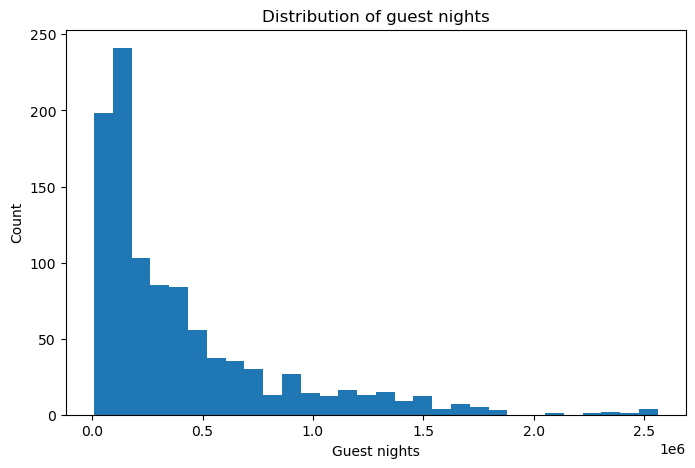

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(df["guest_nights"], bins=30)

plt.xlabel("Guest nights")
plt.ylabel("Count")
plt.title("Distribution of guest nights")

plt.show()

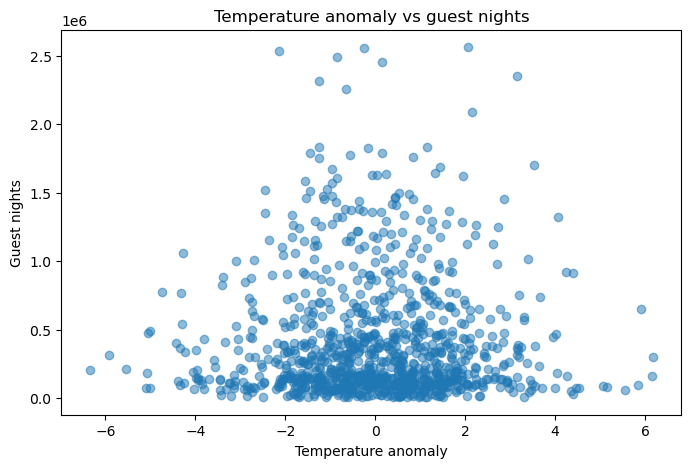

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["temp_anomaly"],
    df["guest_nights"],
    alpha=0.5
)

plt.xlabel("Temperature anomaly")
plt.ylabel("Guest nights")
plt.title("Temperature anomaly vs guest nights")

plt.show()

Omöjligt hitta en korrelation mellan anomalys i värme osv pga, regionala effekter styr på olika sätt.

Testar att göra regression på 3 olika regioner.

In [29]:
regions = ["gotland", "stockholm", "jamtland"]

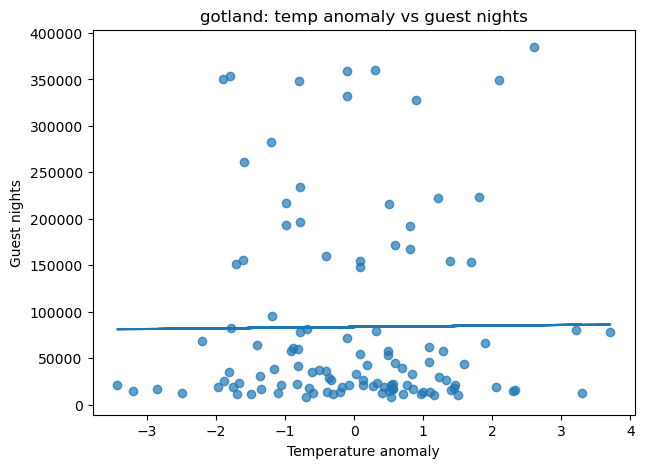

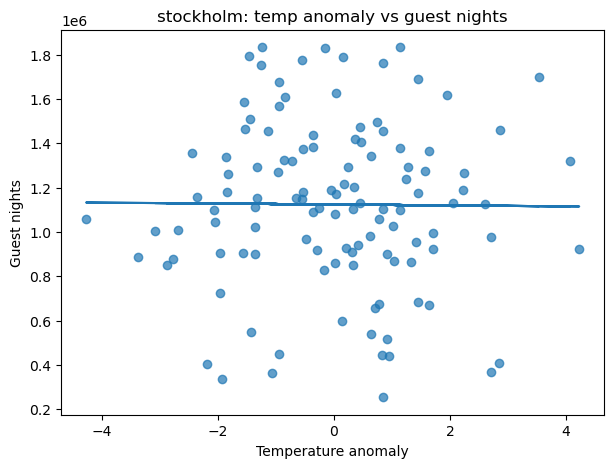

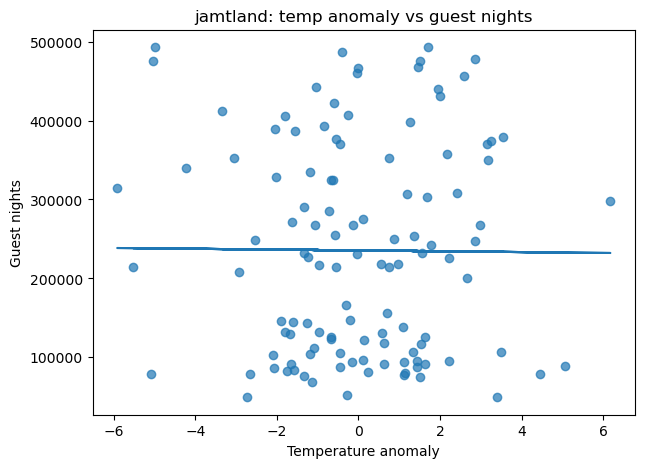

In [30]:
regions = ["gotland", "stockholm", "jamtland"]

for region in regions:

    subset = df[df["region"] == region]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        subset["temp_anomaly"],
        subset["guest_nights"],
        alpha=0.7
    )

    z = np.polyfit(
        subset["temp_anomaly"],
        subset["guest_nights"],
        1
    )

    p = np.poly1d(z)

    plt.plot(
        subset["temp_anomaly"],
        p(subset["temp_anomaly"])
    )

    plt.xlabel("Temperature anomaly")
    plt.ylabel("Guest nights")
    plt.title(f"{region}: temp anomaly vs guest nights")

    plt.show()

Eftersom analysen inkluderar alla månader introduceras mycket säsongsbrus. En ovanligt varm sommarmånad kan rimligen påverka turismen mer på Gotland än en ovanligt varm höstmånad. Samtidigt kan vinterväder vara betydligt viktigare i regioner med vinterturism, exempelvis Jämtland. Därför kan en analys uppdelad efter säsong och region vara mer relevant än en nationell modell över hela året.

In [32]:
summer_df = df[df["month"].isin([6, 7, 8])]

In [33]:
summer_df.shape

(258, 25)

In [34]:
summer_features = [
    "guest_nights",
    "temp_anomaly",
    "sunny_days",
    "mean_sun_hours",
    "rain_days",
    "rain_sum",
    "guest_lag12"
]

summer_df[summer_features].corr()["guest_nights"].sort_values(
    ascending=False
)

guest_nights      1.000000
guest_lag12       0.950520
rain_days         0.099978
rain_sum          0.078231
temp_anomaly     -0.007085
sunny_days       -0.159363
mean_sun_hours   -0.174938
Name: guest_nights, dtype: float64

In [35]:
gotland_summer = summer_df[
    summer_df["region"] == "gotland"
]

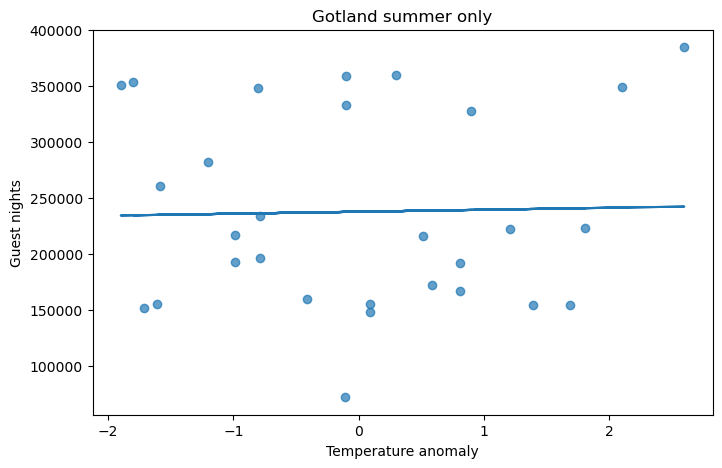

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    gotland_summer["temp_anomaly"],
    gotland_summer["guest_nights"],
    alpha=0.7
)

z = np.polyfit(
    gotland_summer["temp_anomaly"],
    gotland_summer["guest_nights"],
    1
)

p = np.poly1d(z)

plt.plot(
    gotland_summer["temp_anomaly"],
    p(gotland_summer["temp_anomaly"])
)

plt.xlabel("Temperature anomaly")
plt.ylabel("Guest nights")
plt.title("Gotland summer only")

plt.show()

Hitta skillnader i guestnights från året innan och mäta exakt hur stor skillnaden är för att kunna förklara den specifikt.

In [37]:
df["guest_diff_12"] = df["guest_nights"] - df["guest_lag12"]

df["guest_pct_change_12"] = (
    (df["guest_nights"] - df["guest_lag12"]) / df["guest_lag12"]
) * 100

skapa variabel för sommarsäsong och vintersäsong

In [38]:
df_model = df.dropna(subset=[
    "guest_lag12",
    "guest_diff_12",
    "guest_pct_change_12",
    "temp_anomaly"
]).copy()

In [39]:
summer_df = df_model[df_model["month"].isin([6, 7, 8])].copy()
winter_df = df_model[df_model["month"].isin([12, 1, 2, 3])].copy()

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_temp_vs_guest_change(data, region, season_name):
    subset = data[data["region"] == region].copy()

    plt.figure(figsize=(8, 5))

    plt.scatter(
        subset["temp_anomaly"],
        subset["guest_pct_change_12"],
        alpha=0.7
    )

    z = np.polyfit(
        subset["temp_anomaly"],
        subset["guest_pct_change_12"],
        1
    )

    p = np.poly1d(z)

    plt.plot(
        subset["temp_anomaly"],
        p(subset["temp_anomaly"])
    )

    plt.axhline(0, linestyle="--")

    plt.xlabel("Temperature anomaly")
    plt.ylabel("Guest nights change vs last year (%)")
    plt.title(f"{region}: {season_name}")

    plt.show()

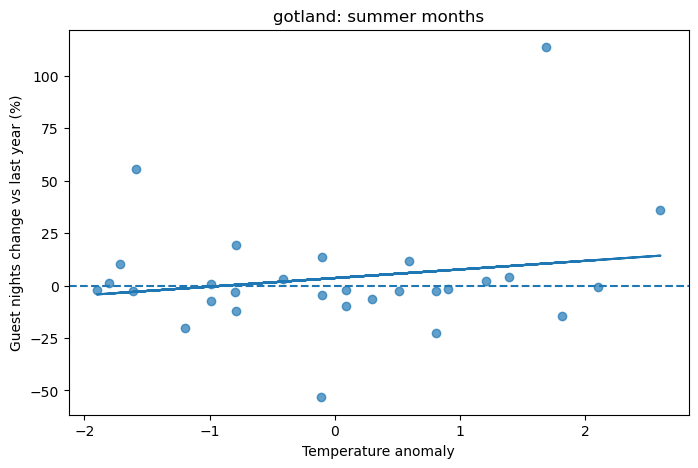

In [41]:
plot_temp_vs_guest_change(
    summer_df,
    "gotland",
    "summer months"
)

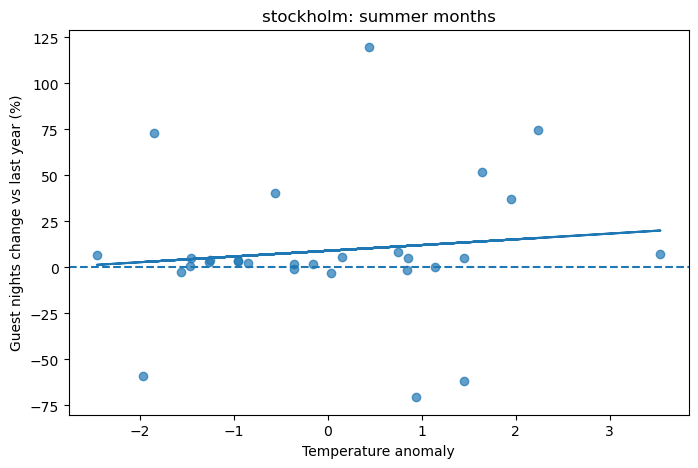

In [42]:
plot_temp_vs_guest_change(
    summer_df,
    "stockholm",
    "summer months"
)

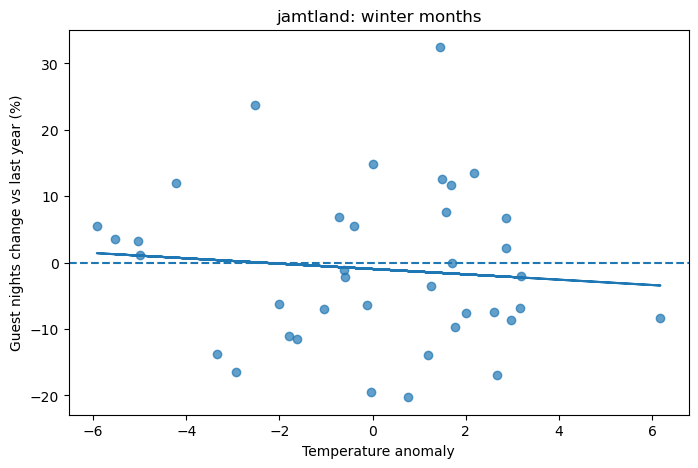

In [43]:
plot_temp_vs_guest_change(
    winter_df,
    "jamtland",
    "winter months"
)

“Givet normalnivån från förra året (guest_lag12), kan temperaturavvikelse hjälpa förklara extra turism?” Vi börjar med linjär regression.

In [44]:
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

Vi kollar bara Gotlands somrar:

In [64]:
gotland = df[df["region"] == "gotland"].copy()

In [65]:
gotland_summer = gotland[
    gotland["month"].isin([6, 7, 8])
].copy()

In [66]:
summer_temp_median = (
    gotland_summer["temp_mean"].median()
)

In [67]:
gotland_summer["warm_summer"] = (
    gotland_summer["temp_mean"] > summer_temp_median
).astype(int)

In [68]:
from sklearn.linear_model import LinearRegression

X = gotland_summer[["warm_summer"]]

y = gotland_summer["guest_nights"]

model = LinearRegression()

model.fit(X, y)

r2 = model.score(X, y)

print("R²:", r2)

print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_[0])

R²: 0.13755785248606167
Intercept: 206913.33333333334
Coefficient: 63871.23809523811


# Linjär regression: Gotlands sommarturism och temperatur

## Syfte

Målet med analysen var att undersöka om varmare sommarmånader på Gotland verkar ha ett samband med högre turismnivåer.

Istället för att försöka förutsäga all turism användes en enklare modell för att undersöka om varma sommarmånader generellt verkar associeras med fler gästnätter.

---

# Modell

En enkel linjär regressionsmodell användes med:

- **Feature (X):**
  - `warm_summer`
    - 1 = varmare sommarmånad än medianen
    - 0 = svalare sommarmånad än medianen

- **Target (y):**
  - `guest_nights`

Analysen inkluderade endast sommarmånader:
- juni
- juli
- augusti

för Gotland.

---

# Resultat

## Modellens förklaringsgrad

R²-värde:

```python
0.137

Testa logistisk regression på Gotland

In [69]:
gotland_summer["high_tourism"] = (
    gotland_summer["guest_nights"]
    >
    gotland_summer["guest_nights"].median()
).astype(int)

In [70]:
gotland_summer["high_tourism"].value_counts()

high_tourism
0    15
1    14
Name: count, dtype: int64

In [71]:
X = gotland_summer[
    [
        "temp_mean",
        "sunny_days",
        "rain_days"
    ]
]

y = gotland_summer["high_tourism"]

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [74]:
model.fit(X_train, y_train)

LogisticRegression()

In [75]:
y_pred = model.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6666666666666666


In [77]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2 0]
 [2 2]]


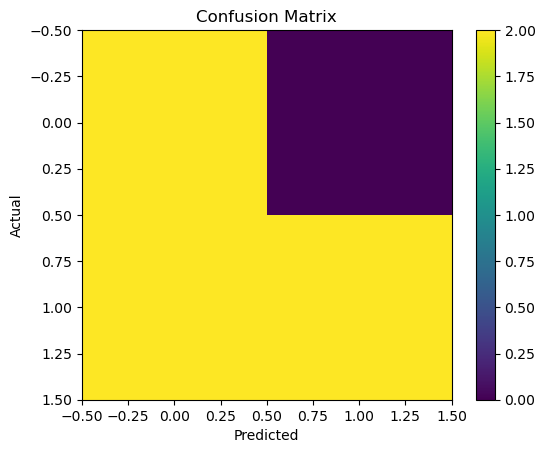

In [78]:
import matplotlib.pyplot as plt

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Det är lite för lite data att bara kolla Gotlands sommarsäsonger eftersom jag bara har 30 st i min data. Så vi testar sommarsäsonger över alla regioner också.

In [79]:
summer_df = df[
    df["month"].isin([6, 7, 8])
].copy()

In [80]:
summer_temp_median = (
    summer_df["temp_mean"].median()
)

In [81]:
summer_df["warm_summer"] = (
    summer_df["temp_mean"] > summer_temp_median
).astype(int)

In [82]:
from sklearn.linear_model import LinearRegression

X = summer_df[["warm_summer"]]

y = summer_df["guest_nights"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [83]:
print("R²:", model.score(X, y))

print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_[0])

R²: 0.07163811815427634
Intercept: 490934.3720930232
Coefficient: 318192.3488372093


Testa log för att bortse från att Stockholm har väldigt mycket fler guestnights än mindre regioner.

In [84]:
summer_df["log_guest_nights"] = np.log(
    summer_df["guest_nights"]
)

In [85]:
from sklearn.linear_model import LinearRegression

X = summer_df[["warm_summer"]]

y = summer_df["log_guest_nights"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [86]:
print("R²:", model.score(X, y))

print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_[0])

R²: 0.09646488443294077
Intercept: 12.735202233014812
Coefficient: 0.5371538199076106


När alla svenska regioner analyseras tillsammans blir sambandet mellan värme och turism relativt svagt. Detta tyder på att vädereffekter sannolikt skiljer sig mellan olika typer av regioner och turismmönster.

Testar dela upp regionerna i mindre grupper.

In [87]:
summer_regions = [
    "gotland",
    "skane",
    "stockholm",
    "vastragotaland"
]

In [88]:
summer_tourism_df = summer_df[
    summer_df["region"].isin(summer_regions)
].copy()

In [89]:
summer_tourism_df.shape

(113, 29)

In [90]:
features = [
    "temp_mean",
    "sunny_days",
    "rain_days"
]

In [91]:
X = summer_tourism_df[features]

y = summer_tourism_df["log_guest_nights"]

In [92]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [93]:
print("R²:", model.score(X, y))

R²: 0.2929085985251707


In [94]:
for feature, coef in zip(features, model.coef_):
    print(feature, coef)

temp_mean 0.2015668959056476
sunny_days -0.12525536422759131
rain_days 0.011591403280599545


Kombinationer av vädervariabler verkar kunna förklara en del av variationen i svensk sommarturism, men sambanden skiljer sig mellan regioner och modellerna påverkas av betydande brus och säsongsvariation.

In [95]:
from sklearn.linear_model import LinearRegression

def run_linear_regression(data, features, target):

    X = data[features]

    y = data[target]

    model = LinearRegression()

    model.fit(X, y)

    r2 = model.score(X, y)

    print("=" * 50)
    print("Features:", features)
    print("Target:", target)
    print("R²:", round(r2, 3))
    print()

    print("Coefficients:")

    for feature, coef in zip(features, model.coef_):
        print(f"{feature}: {coef:.4f}")

    print()

    print("Intercept:", round(model.intercept_, 4))

    return model

In [122]:
summer_tourism_df["temp_x_sun"] = (
    summer_tourism_df["temp_mean"]
    * summer_tourism_df["sunny_days"]
)

In [128]:
feature_sets = [

    ["sunny_days"],

    ["rain_days"],

    ["temp_mean", "sunny_days", "eur"],

    ["temp_mean", "sunny_days", "usd"],

    ["temp_mean", "sunny_days", "temp_x_sun", "usd"],

    ["temp_mean", "sunny_days"],

    ["temp_mean", "sunny_days", "dkk"],

    ["temp_mean", "sunny_days", "eur", "usd"],

    ["temp_mean", "sunny_days", "nok", "dkk"],

    ["temp_mean", "sunny_days", "nok", "dkk", "usd", "eur", "rain_days", "rain_sum"],

]

In [129]:
for features in feature_sets:

    run_linear_regression(
        summer_tourism_df,
        features,
        "log_guest_nights"
    )

Features: ['sunny_days']
Target: log_guest_nights
R²: 0.195

Coefficients:
sunny_days: -0.0875

Intercept: 15.4999
Features: ['rain_days']
Target: log_guest_nights
R²: 0.063

Coefficients:
rain_days: 0.0648

Intercept: 13.0405
Features: ['temp_mean', 'sunny_days', 'eur']
Target: log_guest_nights
R²: 0.295

Coefficients:
temp_mean: 0.1968
sunny_days: -0.1303
eur: 0.0703

Intercept: 12.3313
Features: ['temp_mean', 'sunny_days', 'usd']
Target: log_guest_nights
R²: 0.3

Coefficients:
temp_mean: 0.1990
sunny_days: -0.1307
usd: 0.0920

Intercept: 12.1801
Features: ['temp_mean', 'sunny_days', 'temp_x_sun', 'usd']
Target: log_guest_nights
R²: 0.305

Coefficients:
temp_mean: -0.0006
sunny_days: -0.2752
temp_x_sun: 0.0088
usd: 0.0993

Intercept: 15.3481
Features: ['temp_mean', 'sunny_days']
Target: log_guest_nights
R²: 0.292

Coefficients:
temp_mean: 0.1965
sunny_days: -0.1298

Intercept: 13.0703
Features: ['temp_mean', 'sunny_days', 'dkk']
Target: log_guest_nights
R²: 0.295

Coefficients:
temp_

Vi kör med split för att testa på riktig data.

In [102]:
from sklearn.model_selection import train_test_split

X = summer_tourism_df[
    [
        "temp_mean",
        "sunny_days",
        "eur",
        "usd"
    ]
]

y = summer_tourism_df["log_guest_nights"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [104]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("Test R²:", r2)

Test R²: -0.014258376165114495


Blev helt värdelös på testdata. Kanske pga för lite data. Testa lite Random Forest

In [112]:
summer_tourism_df["temp_x_sun"] = (
    summer_tourism_df["temp_mean"]
    * summer_tourism_df["sunny_days"]
)

In [119]:
run_linear_regression(
    summer_tourism_df,
    ["temp_x_sun", "temp_mean", "usd","rain_days", "sunny_days"],
    "log_guest_nights"
)

Features: ['temp_x_sun', 'temp_mean', 'usd', 'rain_days', 'sunny_days']
Target: log_guest_nights
R²: 0.305

Coefficients:
temp_x_sun: 0.0089
temp_mean: 0.0021
usd: 0.0964
rain_days: 0.0086
sunny_days: -0.2725

Intercept: 15.1789


LinearRegression()

In [120]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

In [130]:
rf_features = [
    "temp_x_sun",
    "temp_mean",
    "usd",
    "rain_days",
    "sunny_days"
]

In [132]:
X = summer_tourism_df[rf_features]

y = summer_tourism_df["log_guest_nights"]

In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [134]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

In [135]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=4, random_state=42)

In [136]:
y_pred = rf_model.predict(X_test)

In [137]:
r2 = r2_score(y_test, y_pred)

print("Random Forest Test R²:", r2)

Random Forest Test R²: -0.13251591243660288


Samma kassa träningsdata dock.

In [138]:
for feature, importance in zip(
    rf_features,
    rf_model.feature_importances_
):
    print(feature, round(importance, 3))

temp_x_sun 0.171
temp_mean 0.235
usd 0.098
rain_days 0.08
sunny_days 0.417


In [139]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": rf_features,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
4,sunny_days,0.416580
1,temp_mean,0.234722
0,temp_x_sun,0.170739
2,usd,0.098289
3,rain_days,0.079670


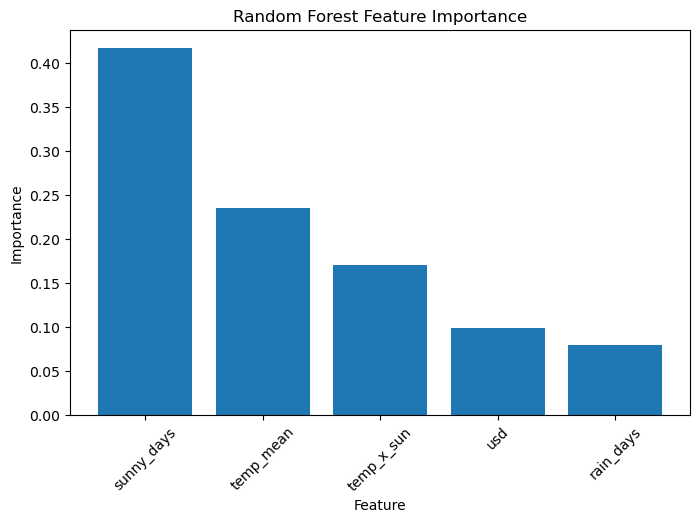

In [140]:
plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")

plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()

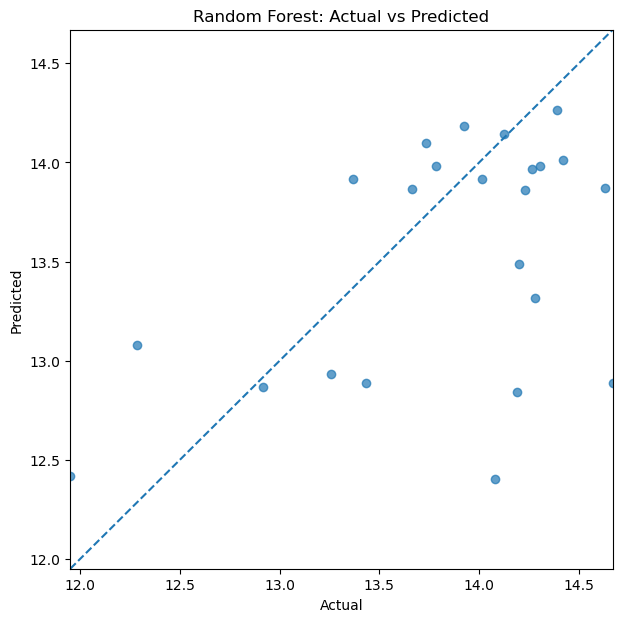

In [142]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Random Forest: Actual vs Predicted")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.show()

Modellen verkar kunna fånga vissa övergripande samband mellan väder och turism, men predictionerna innehåller fortfarande betydande osäkerhet och brus.

In [147]:
from sklearn.metrics import r2_score

rf_r2 = r2_score(y_test, y_pred)

print("Random Forest Test R²:", rf_r2)

Random Forest Test R²: -0.13251591243660288


Mer komplexa modeller förbättrade anpassningen till träningsdatan men generaliserade sämre till testdatan, vilket tyder på överanpassning och begränsad mängd observationer.

Testar PCA och UMAP

In [163]:
weather_features = [
    "temp_mean",
    "sunny_days",
    "rain_days",
    "rain_sum",
    "rain_mean",
    "mean_sun_hours",
    "total_sun_hours",
    "temp_month_avg",
]

In [164]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    summer_tourism_df[weather_features]
)

In [165]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

In [166]:
summer_tourism_df["pc1"] = components[:, 0]

summer_tourism_df["pc2"] = components[:, 1]

In [167]:
print(
    pca.explained_variance_ratio_
)

[0.64706539 0.16500623]


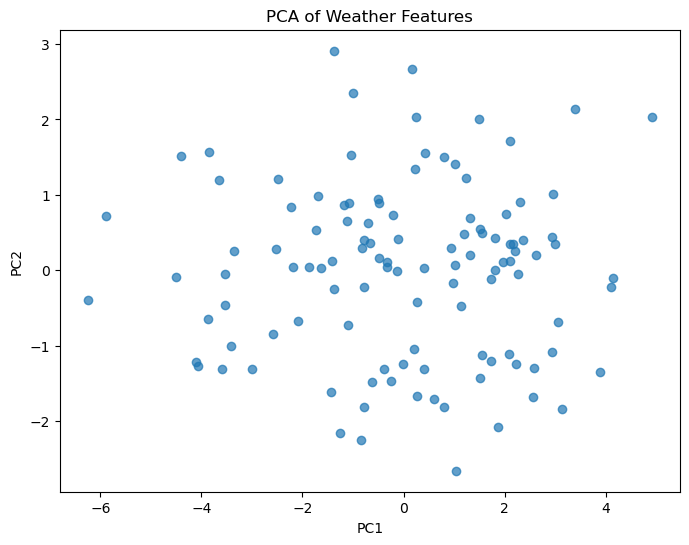

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    summer_tourism_df["pc1"],
    summer_tourism_df["pc2"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA of Weather Features")

plt.show()

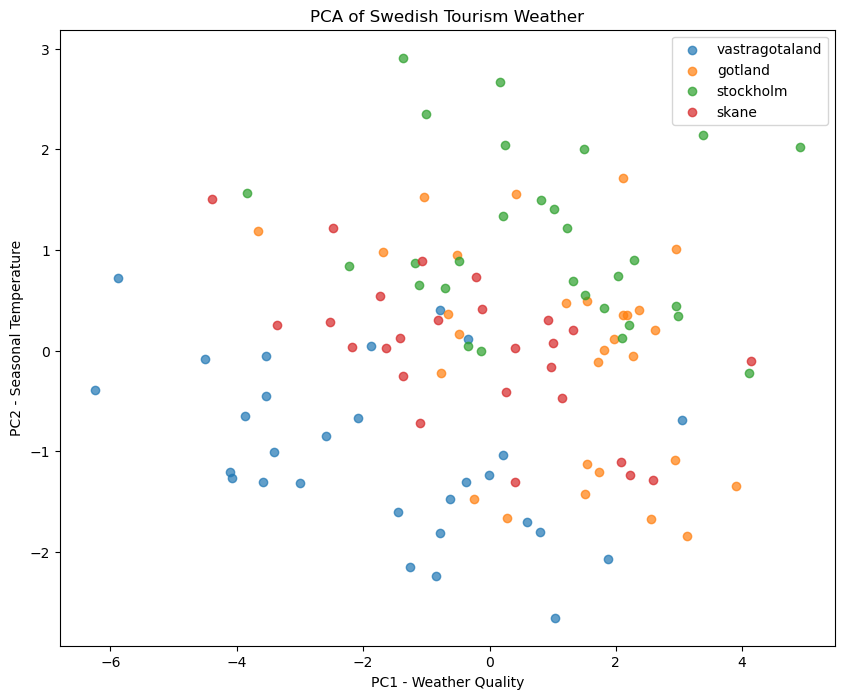

In [171]:
plt.figure(figsize=(10, 8))

regions = summer_tourism_df["region"].unique()

for region in regions:

    subset = summer_tourism_df[
        summer_tourism_df["region"] == region
    ]

    plt.scatter(
        subset["pc1"],
        subset["pc2"],
        label=region,
        alpha=0.7
    )

plt.xlabel("PC1 - Weather Quality")
plt.ylabel("PC2 - Seasonal Temperature")

plt.title("PCA of Swedish Tourism Weather")

plt.legend()

plt.show()

In [170]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=weather_features
)

loadings

,PC1,PC2
temp_mean,0.293610,0.500480
sunny_days,0.394909,0.102013
rain_days,-0.367702,0.212555
rain_sum,-0.372355,0.253613
rain_mean,-0.372249,0.245610
mean_sun_hours,0.399604,-0.063196
total_sun_hours,0.403503,-0.029005
temp_month_avg,0.151397,0.751302


Det finns vissa regionala skillnader i vädermönster, men variationen inom regionerna är fortfarande stor och regionerna överlappar varandra betydligt.

Vi testade flera supervised ML-modeller för att undersöka om väder verkar påverka turism i Sverige, mätt som guest_nights per region och månad.

När alla regioner och månader analyserades samtidigt blev sambanden mycket svaga. Det verkar rimligt eftersom olika regioner har olika typer av turism och säsongsmönster, exempelvis vinterturism i Jämtland och sommarturism på Gotland.

När analysen istället begränsades till sommarregioner och sommarmånader ökade modellernas förklaringsgrad till ungefär R² ≈ 0.3 i vissa linjära regressionsmodeller på träningsdatan. Det antyder att väder verkar kunna förklara en viss del av variationen i turism för vissa regioner, även om sambanden fortfarande är relativt svaga och brusiga.

De starkaste variablerna totalt var lag features som guest_lag12, vilket är logiskt eftersom turismnivåer ofta liknar föregående års nivåer.

Vi testade även Random Forest och PCA:
- Random Forest gav bättre anpassning till träningsdatan men generaliserade dåligt på testdata, vilket tyder på overfitting och begränsad mängd observationer.
- PCA visade att vädervariablerna till stor del kunde sammanfattas i några få komponenter, där den första komponenten tydligt representerade "bra sommarväder" med mer sol och mindre regn.

Slutsatsen är främst explorativ:
väder verkar ha viss betydelse för turism i vissa sommarregioner, men sambanden är komplexa och datamängden är för liten för stark predictive power.